In [1]:
!pip install lightly #good library for contrastive learning based on google search
!pip install scikit-learn
!pip install numpy
!pip install pandas
!pip install opencv-python
!pip install matplotlib
!pip install torch
!pip install torchvision
!pip install tqdm
!pip install logging
!pip uninstall -y sympy
!pip install sympy==1.14.0

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)


In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from lightly.models.modules import heads
from lightly.loss import NTXentLoss
from lightly.transforms import SimCLRTransform
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.datasets import CIFAR10, ImageNet
from cub2011 import Cub2011 # Adapted from https://github.com/lvyilin/pytorch-fgvc-dataset/blob/master/cub2011.py
import torchvision.models as models
import random
from tqdm import tqdm
import sklearn.preprocessing
import logging
import sklearn.cluster
import sklearn.metrics.cluster
import gc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def graph_losses(losses, title):
    plt.plot(losses)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

# Independent Variables
These lists as defined here represent the different training parameters to be compared. They include the amount of epochs used in training and selection of the base mode. A model will be trained and tested for the cartesian product of these sets for both ProxyNCA and NT-Xent.

In [ ]:
epochs = [10, 50]
#epochs = [2]
model_types = [(models.resnet18, "resnet18"), (models.resnet50, "resnet50"), (models.resnet101, "resnet101")]
#model_types = [(models.resnet18, "resnet18"), (models.resnet50, "resnet50")]

# Transform pipeline
Apply random crop, horizontal flip, color jitter, grayscale. Blur, then return as tensor.

In [9]:
simclr_transform = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(0.4,0.4,0.4,0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=3),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

# Evaluation Pipeline

In [4]:
evaluation_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

# Dataset
Create two views (xi, xj) of the given image from the dataset.

In [5]:
class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        xi = self.transform(image)
        xj = self.transform(image)
        return xi, xj

    def __len__(self):
        return len(self.dataset)

# SimCLR Model
- Encoder: ResNet18, ResNet50, ResNet101
- Projection Head: maps features from encoder to 128-Dimensional Contrastive Space
- Output: contrastive loss $z$

In [6]:
class SimCLRModel(nn.Module):
    def __init__(self, model, weights='DEFAULT', projection_dim=128):
        super().__init__()
        base_model = model(weights=weights)
        num_ftrs = base_model.fc.in_features
        base_model.fc = nn.Identity()
        self.encoder = base_model
        self.projection_head = nn.Sequential(
            nn.Linear(num_ftrs, 2048),
            nn.ReLU(),
            nn.Linear(2048, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return z

def extract_embeddings_labels(model, loader):
    embeddings, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model(x)
            embeddings.append(z.cpu())
            labels.append(y)
    return torch.cat(embeddings), torch.cat(labels)

# Loss Function
NT-Xent

In [7]:
def nt_xent_loss(z_i, z_j, temperature=0.05):
    z = torch.cat([z_i, z_j], dim=0)
    z = F.normalize(z, dim=1)

    similarity = torch.matmul(z, z.T)
    N = z_i.shape[0]

    mask = (~torch.eye(2*N, dtype=bool)).to(z.device)
    sim = similarity / temperature
    exp_sim = torch.exp(sim) * mask

    positive_sim = torch.exp(F.cosine_similarity(z_i, z_j) / temperature)
    positives = torch.cat([positive_sim, positive_sim], dim=0)

    denominator = exp_sim.sum(dim=1)
    loss = -torch.log(positives / denominator)
    return loss.mean()

# Load the Dataset

In [10]:
train_dataset = Cub2011(root=str('./cub2011'), train=True, download=True)
contrastive_dataset = SimCLRDataset(train_dataset, simclr_transform)
train_loader = DataLoader(contrastive_dataset, batch_size=128, shuffle=True, num_workers=2)

Files already downloaded and verified


# SimCLR Training Loop

Epochs: 10, Model Type: resnet18


100%|██████████| 47/47 [00:20<00:00,  2.35it/s]


Epoch 1 | Loss: 5.3684


100%|██████████| 47/47 [00:19<00:00,  2.36it/s]


Epoch 2 | Loss: 5.4381


...

Epoch 8 | Loss: 3.5752


100%|██████████| 47/47 [00:19<00:00,  2.37it/s]


Epoch 9 | Loss: 3.3543


100%|██████████| 47/47 [00:20<00:00,  2.34it/s]

Epoch 10 | Loss: 3.0236


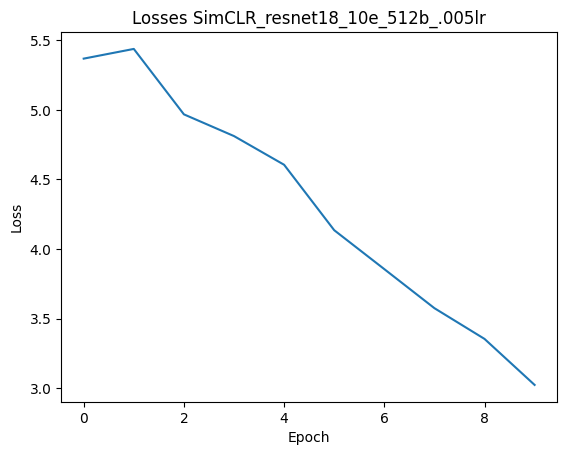

Epochs: 10, Model Type: resnet50


100%|██████████| 47/47 [00:20<00:00,  2.32it/s]


Epoch 1 | Loss: 5.1206


100%|██████████| 47/47 [00:20<00:00,  2.32it/s]


Epoch 2 | Loss: 4.3474


...

Epoch 8 | Loss: 1.4880


100%|██████████| 47/47 [00:20<00:00,  2.33it/s]


Epoch 9 | Loss: 1.3700


100%|██████████| 47/47 [00:20<00:00,  2.31it/s]

Epoch 10 | Loss: 1.2722


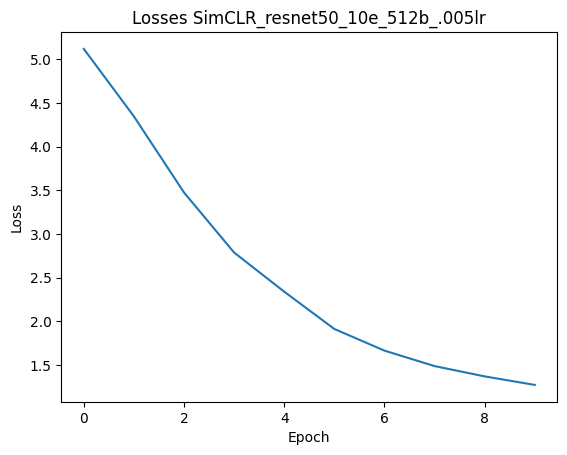

Epochs: 10, Model Type: resnet101


100%|██████████| 47/47 [00:21<00:00,  2.17it/s]


Epoch 1 | Loss: 4.8763


100%|██████████| 47/47 [00:21<00:00,  2.15it/s]


Epoch 2 | Loss: 3.9932


...

Epoch 8 | Loss: 1.3746


100%|██████████| 47/47 [00:21<00:00,  2.16it/s]


Epoch 9 | Loss: 1.2712


100%|██████████| 47/47 [00:21<00:00,  2.18it/s]

Epoch 10 | Loss: 1.1804


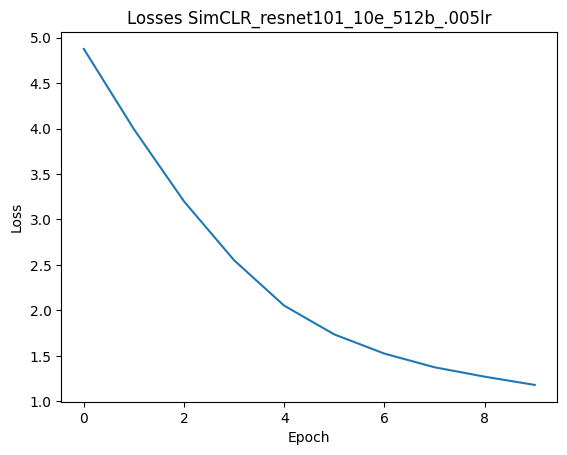

Epochs: 50, Model Type: resnet18


100%|██████████| 47/47 [00:19<00:00,  2.35it/s]


Epoch 1 | Loss: 5.3446


100%|██████████| 47/47 [00:20<00:00,  2.34it/s]


Epoch 2 | Loss: 5.5147


...

Epoch 48 | Loss: 0.9468


100%|██████████| 47/47 [00:19<00:00,  2.40it/s]


Epoch 49 | Loss: 0.8950


100%|██████████| 47/47 [00:19<00:00,  2.42it/s]

Epoch 50 | Loss: 0.9326


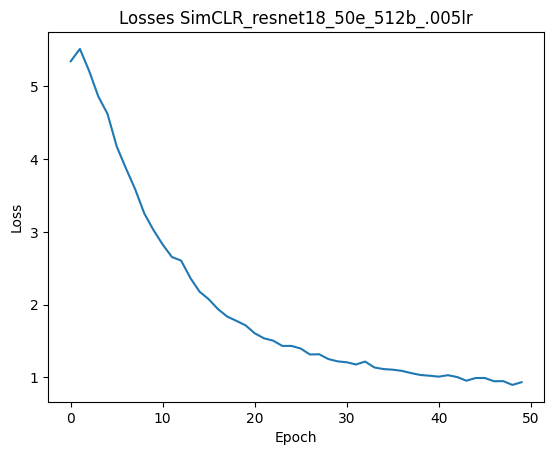

Epochs: 50, Model Type: resnet50


100%|██████████| 47/47 [00:19<00:00,  2.37it/s]


Epoch 1 | Loss: 5.2762


100%|██████████| 47/47 [00:19<00:00,  2.38it/s]


Epoch 2 | Loss: 4.9493


...

Epoch 48 | Loss: 0.5968


100%|██████████| 47/47 [00:19<00:00,  2.37it/s]


Epoch 49 | Loss: 0.6241


100%|██████████| 47/47 [00:19<00:00,  2.37it/s]

Epoch 50 | Loss: 0.6084


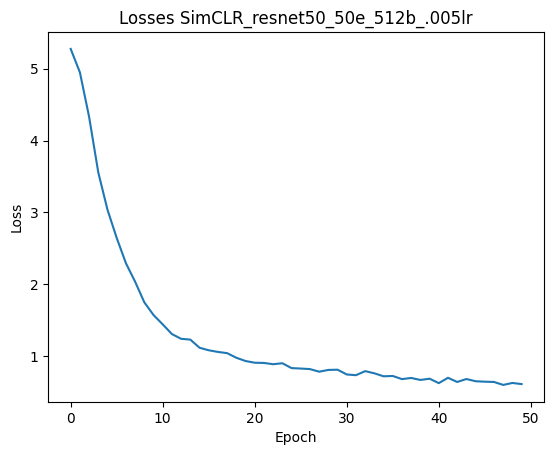

Epochs: 50, Model Type: resnet101


100%|██████████| 47/47 [00:20<00:00,  2.25it/s]


Epoch 1 | Loss: 4.9965


100%|██████████| 47/47 [00:21<00:00,  2.23it/s]


Epoch 2 | Loss: 4.1257


...

Epoch 48 | Loss: 0.6293


100%|██████████| 47/47 [00:21<00:00,  2.14it/s]


Epoch 49 | Loss: 0.6491


100%|██████████| 47/47 [00:21<00:00,  2.14it/s]

Epoch 50 | Loss: 0.6153


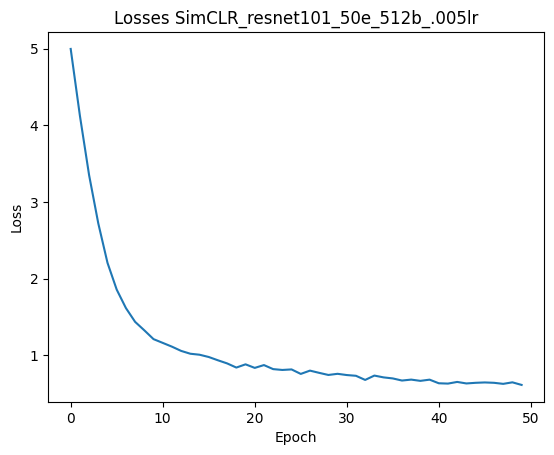

Training completed!


In [10]:
for num_epochs in epochs:
    for model_type in model_types:
        model = SimCLRModel(model_type[0], weights='DEFAULT').to(device)
        #https://discuss.pytorch.org/t/passing-to-the-optimizers-frozen-parameters/83358
        #https://discuss.pytorch.org/t/how-can-i-exclude-some-parameters-in-optimizer-during-training/90208
        #https://discuss.pytorch.org/t/best-practice-for-freezing-layers/58156
        # Freeze the encoder weights, only train the projection head
        for param in model.encoder.parameters():
                param.requires_grad = False
        
        optimizer = torch.optim.Adam(model.parameters(), lr=.005)
        #https://www.kozodoi.me/blog/gradient-accumulation-in-pytorch
        #https://wandb.ai/wandb_fc/tips/reports/How-To-Implement-Gradient-Accumulation-in-PyTorch--VmlldzoyMjMwOTk5
        accumulate_batches = 4

        print("Epochs: " + str(num_epochs) + ", Model Type: " + model_type[1])
        
        losses = []
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0.0
            optimizer.zero_grad()
            for i, samples in enumerate(tqdm(train_loader)):
                x_i, x_j = samples
                x_i = x_i.to(device)
                x_j = x_j.to(device)
                z_i = model(x_i)
                z_j = model(x_j)
        
                loss = nt_xent_loss(z_i, z_j)
                loss = loss/accumulate_batches
                loss.backward()
        
                if (i+1) % accumulate_batches == 0:
                    optimizer.step()
                    optimizer.zero_grad()
        
                total_loss += loss.item() * accumulate_batches
        
        
            if(len(train_loader) % accumulate_batches != 0):
                optimizer.step()
                optimizer.zero_grad()
        
            losses.append(total_loss/len(train_loader))
            print(f"Epoch {epoch+1} | Loss: {total_loss / len(train_loader):.4f}")

            if epoch % 5 == 0:
                torch.save(model.state_dict(), "SimCLR_" + model_type[1] + "_" + str(num_epochs) + "e_512b_.005lr.pth")

        graph_losses(losses, "Losses SimCLR_" + model_type[1] + "_" + str(num_epochs) + "e_512b_.005lr")
        with open("simclr_losses_frozen.txt", "a", encoding='utf-8') as f:
            f.write("SimCLR_" + model_type[1] + "_" + str(num_epochs) + "e_512b_.005lr.pth: " + str(losses) + "\n")

        del model
        del optimizer
        gc.collect()
        with torch.no_grad():
            torch.cuda.empty_cache()

print("Training completed!")

# SimCLR Evaluation

In [ ]:
def recall_at_k(embeddings, labels, k=3):
    correct = 0
    numEmbeddings = len(labels)
    for i in range(numEmbeddings):
        current_embedding = embeddings[i]
        dist = torch.norm(embeddings - current_embedding, dim=1, p = None)
        dist[i] = float('inf')
        k_nearest = dist.topk(k, largest=False)
        for idx in k_nearest.indices:
            if labels[idx] == labels[i]:
                correct += 1
                break
    return correct / numEmbeddings

for num_epochs in epochs:
    for model_type in model_types:
        model = SimCLRModel(model_type[0], projection_dim=128).to(device)
        model.load_state_dict(torch.load("SimCLR_" + model_type[1] + "_" + str(num_epochs) + "e_512b_.005lr.pth", map_location=device))
        model.eval()
        
        test_dataset = Cub2011(root='./cub2011', train=False, download=False, transform=evaluation_transform)
        test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)
        
        embeddings, labels = extract_embeddings_labels(model, test_loader)
        r_at_1 = recall_at_k(embeddings, labels, k=1)
        r_at_3 = recall_at_k(embeddings, labels, k=3)
        r_at_5 = recall_at_k(embeddings, labels, k=5)
        r_at_10 = recall_at_k(embeddings, labels, k=10)
        print(model_type[1], "Epochs: " + str(num_epochs))
        print(f"R@1: {r_at_1:.4f}, R@3: {r_at_3:.4f}, R@5: {r_at_5:.4f}, R@10: {r_at_10:.4f}")

resnet18 Epochs: 10
R@1: 0.0102, R@3: 0.0278, R@5: 0.0444, R@10: 0.0825
resnet50 Epochs: 10
R@1: 0.0105, R@3: 0.0307, R@5: 0.0466, R@10: 0.0823
resnet18 Epochs: 50
R@1: 0.0349, R@3: 0.0777, R@5: 0.1153, R@10: 0.1930
resnet50 Epochs: 50
R@1: 0.0307, R@3: 0.0766, R@5: 0.1099, R@10: 0.1836


# ProxyNCA Model

In [3]:
def binarize_and_smooth_labels(T, nb_classes, smoothing_const=0.1):
    T = T.cpu().numpy()
    T = sklearn.preprocessing.label_binarize(T, classes=range(nb_classes))
    T = T * (1 - smoothing_const)
    T[T == 0] = smoothing_const / (nb_classes - 1)
    return torch.FloatTensor(T).to(device)

class ProxyNCA(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, smoothing_const=0.1,
                 scaling_x=1.0, scaling_p=3.0):
        super().__init__()
        self.proxies = nn.Parameter(torch.randn(num_classes, embedding_dim) / 8)
        self.smoothing_const = smoothing_const
        self.scaling_x = scaling_x
        self.scaling_p = scaling_p
        self.num_classes = num_classes

    def forward(self, z, labels):
        P = F.normalize(self.proxies, p=2, dim=-1) * self.scaling_p
        Z = F.normalize(z, p=2, dim=-1) * self.scaling_x

        D = torch.cdist(Z, P) ** 2

        T = binarize_and_smooth_labels(labels, self.num_classes, self.smoothing_const)
        loss = torch.sum(-T * F.log_softmax(-D, dim=-1), dim=-1)
        return loss.mean()

# ProxyNCA Training Loop

In [8]:
#transform images for proxy
proxy_transform = T.Compose([
    T.Resize(64),
    T.RandomCrop(32),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
proxy_train_dataset = Cub2011(root='./cub2011', train=True, download=True, transform=proxy_transform)
proxy_train_loader = DataLoader(proxy_train_dataset, batch_size=512, shuffle=True, num_workers=2)

for num_epochs in epochs:
    for model_type in model_types:
        base = model_type[0](weights=None)
        embedding_dim = base.fc.in_features
        base.fc = nn.Identity()
        encoder = base.to(device)
        #for param in encoder.parameters():
        #        param.requires_grad = False
    
        proxy_loss_fn = ProxyNCA(
            num_classes=100, #split training and tesing
            embedding_dim=embedding_dim,
        ).to(device)
    
        optimizer = torch.optim.Adam(
            list(encoder.parameters()) + list(proxy_loss_fn.parameters()),
            lr=.005,
            weight_decay=1e-4
        )
    
        for epoch in range(num_epochs):
            encoder.train()
            proxy_loss_fn.train()
            total_loss = 0
            for images, labels in tqdm(proxy_train_loader):
                images, labels = images.to(device), labels.to(device)
                z = encoder(images)
    
                loss = proxy_loss_fn(z, labels)
    
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
    
            print(f"epoch {epoch+1} | Loss: {total_loss / len(proxy_train_loader):.4f}")
    
        torch.save({'encoder': encoder.state_dict(),'proxies': proxy_loss_fn.state_dict()}, "ProxyNCA_" + model_type[1] + "_" + str(num_epochs) + "e_512b_.005lr.pth")
print("Training Complete!")

Files already downloaded and verified


100%|█████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.15it/s]


epoch 1 | Loss: 2.5424


100%|█████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.19it/s]


epoch 2 | Loss: 2.4893


...

epoch 48 | Loss: 2.1202


100%|█████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.01it/s]


epoch 49 | Loss: 2.1306


100%|█████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.06it/s]


epoch 50 | Loss: 2.1219


# ProxyNCA Evaluation

In [9]:
evaluation_transform_NCA = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))])

def calc_recall_at_k(T, Y, k):
    """
    T : [nb_samples] (target labels)
    Y : [nb_samples x k] (k predicted labels/neighbours)
    """
    s = sum([1 for t, y in zip(T, Y) if t in y[:k]])
    return s / (1. * len(T))

def assign_by_euclidian_at_k(X, T, k):
    """
    X : [nb_samples x nb_features], e.g. 100 x 64 (embeddings)
    k : for each sample, assign target labels of k nearest points
    """
    distances = torch.cdist(X, X)
    # get nearest points
    indices = distances.topk(k + 1, largest=False)[1][:, 1: k + 1]
    return np.array([[T[i] for i in ii] for ii in indices])

def cluster_by_kmeans(X, nb_clusters):
    """
    xs : embeddings with shape [nb_samples, nb_features]
    nb_clusters : in this case, must be equal to number of classes
    """
    return sklearn.cluster.KMeans(nb_clusters).fit(X).labels_

def calc_normalized_mutual_information(ys, xs_clustered):
    return sklearn.metrics.cluster.normalized_mutual_info_score(xs_clustered, ys)

def predict_batchwise(model, dataloader):
    # list with N lists, where N = |{image, label, index}|
    model_is_training = model.training
    model.eval()
    ds = dataloader.dataset
    A = [[] for i in range(len(ds[0]))]
    with torch.no_grad():

        # extract batches (A becomes list of samples)
        for batch in dataloader:
            for i, J in enumerate(batch):
                # i = 0: sz_batch * images
                # i = 1: sz_batch * labels
                # i = 2: sz_batch * indices
                if i == 0:
                    # move images to device of model (approximate device)
                    J = J.to(list(model.parameters())[0].device)
                    # predict model output for image
                    J = model(J).cpu()
                for j in J:
                    A[i].append(j)
    model.train()
    model.train(model_is_training) # revert to previous training state
    return [torch.stack(A[i]) for i in range(len(A))]

def evaluate(model, dataloader, with_nmi = True):
    nb_classes = dataloader.dataset.nb_classes()

    # calculate embeddings with model and get targets
    X, T, *_ = predict_batchwise(model, dataloader)

    if with_nmi:
        # calculate NMI with kmeans clustering
        nmi = calc_normalized_mutual_information(
            T,
            cluster_by_kmeans(
                X, nb_classes
            )
        )
        print("NMI: {:.3f}".format(nmi * 100))

    # get predictions by assigning nearest 8 neighbors with euclidian
    Y = assign_by_euclidian_at_k(X, T, 8)
    Y = torch.from_numpy(Y)

    # calculate recall @ 1, 3, 5, 10
    recall = []
    for k in [1, 3, 5, 10]:
        r_at_k = calc_recall_at_k(T, Y, k)
        recall.append(r_at_k)
        print("R@{} : {:.3f}".format(k, 100 * r_at_k))
    if with_nmi:
        return recall, nmi
    else:
        return recall

for num_epochs in epochs:
    for model_type in model_types:
        # Initialize the base encoder model (ResNet50 without the final classification layer)
        base_model = model_type[0](weights='DEFAULT')
        embedding_dim = base_model.fc.in_features
        base_model.fc = nn.Identity()
        encoder_model = base_model.to(device)
        
        # Initialize the ProxyNCA loss function (num_classes from training, embedding_dim from resnet50)
        proxy_nca_loss_fn = ProxyNCA(num_classes=100, embedding_dim=embedding_dim).to(device)
        
        # Load the saved state dictionaries for both encoder and proxies
        checkpoint = torch.load("ProxyNCA_" + model_type[1] + "_" + str(num_epochs) + "e_512b_.005lr.pth", map_location=device)
        encoder_model.load_state_dict(checkpoint['encoder'])
        proxy_nca_loss_fn.load_state_dict(checkpoint['proxies'])
        
        # Set models to evaluation mode
        encoder_model.eval()
        proxy_nca_loss_fn.eval()
        
        # Load dataset for evaluation
        test_dataset = Cub2011(root='./cub2011', train=False, download=True, transform=evaluation_transform_NCA)
        # Fix: Add nb_classes method to the dataset instance
        test_dataset.nb_classes = lambda: 200 # Cub2011 dataset has 200 classes
        test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=2)
        
        with torch.no_grad():
            logging.info("**Evaluating...**")
            # Pass the encoder_model for evaluation, as it produces the embeddings
            evaluate(encoder_model, test_loader)

Files already downloaded and verified
NMI: 37.239
R@1 : 1.243
R@3 : 2.710
R@5 : 4.177
R@10 : 6.351
Files already downloaded and verified
NMI: 31.984
R@1 : 1.087
R@3 : 2.416
R@5 : 4.073
R@10 : 6.162
Files already downloaded and verified
NMI: 33.116
R@1 : 1.398
R@3 : 2.692
R@5 : 3.849
R@10 : 5.230
Files already downloaded and verified
NMI: 38.842
R@1 : 2.295
R@3 : 5.471
R@5 : 8.492
R@10 : 12.375
Files already downloaded and verified
NMI: 38.724
R@1 : 1.622
R@3 : 4.367
R@5 : 6.714
R@10 : 9.941
Files already downloaded and verified
NMI: 35.288
R@1 : 1.433
R@3 : 3.383
R@5 : 5.178
R@10 : 7.991
Files already downloaded and verified
NMI: 38.884
R@1 : 3.952
R@3 : 9.027
R@5 : 13.324
R@10 : 18.260
Files already downloaded and verified
NMI: 39.933
R@1 : 4.936
R@3 : 10.753
R@5 : 15.499
R@10 : 21.125
Files already downloaded and verified
NMI: 37.499
R@1 : 3.970
R@3 : 9.631
R@5 : 13.859
R@10 : 19.348
